# 03. Prophet — Cluster Level

29개 제조업체를 4개 클러스터로 묶은 뒤 Prophet을 적용한 노트북입니다.

- 판매량 기준 greedy bin-packing 클러스터링
- 2023-05 cluster 4 이상치 보정
- 클러스터 단위 Prophet MAPE 38.61%

### 독립변수 조정
- 제조업체별 예측 ( ~제조업체별 판매횟수~ or 판매수량)
- ~중분류별 예측 (라면류, 면류, 기타면류)~
- 코로나 데이터 유무 (default : 제외하고, 위에서 성능 좋았던 경우에 추가)
- ~휴가 관련 데이터 추가~

---
### 모델 조정
- SARIMA 기반 예측
- 트리기반 모델 앙상블 (시계열 + 회귀 가능한 모델 search)

---
### 파라미터 조정
- 

In [25]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import prophet

In [26]:
final = pd.read_csv('../data/final.csv', encoding='utf-8-sig')
final

,판매월,제조업체,상품명,판매수량,대분류,중분류,한파,폭염,호우,생활물가지수,음식료품_계절조정지수
0,2021-01,88010455.0,(오뚜기)열라면종이(용기)105g,1.0,면류.라면류,라면류,22,0,0,101.20,105.5
1,2021-01,88030600.0,(백제물산)즉석쌀국수멸치맛92g,2.0,면류.라면류,면류,22,0,0,101.20,105.5
2,2021-01,88030600.0,(백제물산)즉석쌀국수멸치맛92g,1.0,면류.라면류,면류,22,0,0,101.20,105.5
3,2021-01,88010455.0,(오뚜기)열라면종이(용기)105g,2.0,면류.라면류,라면류,22,0,0,101.20,105.5
4,2021-01,88010455.0,(오뚜기)열라면종이(용기)105g,1.0,면류.라면류,라면류,22,0,0,101.20,105.5
...,...,...,...,...,...,...,...,...,...,...,...
80578,2024-02,NaN,NaN,NaN,NaN,NaN,2,0,12,116.32,91.0
80579,2024-03,NaN,NaN,NaN,NaN,NaN,5,0,6,116.62,94.5
80580,2024-04,NaN,NaN,NaN,NaN,NaN,0,0,0,116.59,94.0
80581,2024-05,NaN,NaN,NaN,NaN,NaN,0,0,21,116.53,94.6


---

In [27]:
final_1 = final.copy()
final_1.drop(columns=['상품명', '대분류', '중분류'], inplace=True)

In [28]:
final_1

,판매월,제조업체,판매수량,한파,폭염,호우,생활물가지수,음식료품_계절조정지수
0,2021-01,88010455.0,1.0,22,0,0,101.20,105.5
1,2021-01,88030600.0,2.0,22,0,0,101.20,105.5
2,2021-01,88030600.0,1.0,22,0,0,101.20,105.5
3,2021-01,88010455.0,2.0,22,0,0,101.20,105.5
4,2021-01,88010455.0,1.0,22,0,0,101.20,105.5
...,...,...,...,...,...,...,...,...
80578,2024-02,NaN,NaN,2,0,12,116.32,91.0
80579,2024-03,NaN,NaN,5,0,6,116.62,94.5
80580,2024-04,NaN,NaN,0,0,0,116.59,94.0
80581,2024-05,NaN,NaN,0,0,21,116.53,94.6


In [29]:
# 2024년 데이터 삭제
final_1['판매월'] = pd.to_datetime(final_1['판매월'], format='%Y-%m')
final_1 = final_1[final_1['판매월'].dt.year != 2024]

In [30]:
# 월별, 제조업체별 판매수량 합산
final_1 = final_1.groupby(['판매월', '제조업체'], as_index=False).agg({
    '판매수량': 'sum',
    '한파': 'first',
    '폭염': 'first',
    '호우': 'first',
    '생활물가지수': 'first',
    '음식료품_계절조정지수': 'first'
})

final_1

,판매월,제조업체,판매수량,한파,폭염,호우,생활물가지수,음식료품_계절조정지수
0,2021-01-01,88010249.0,4.0,22,0,0,101.20,105.5
1,2021-01-01,88010430.0,3719.0,22,0,0,101.20,105.5
2,2021-01-01,88010438.0,127.0,22,0,0,101.20,105.5
3,2021-01-01,88010453.0,450.0,22,0,0,101.20,105.5
4,2021-01-01,88010454.0,229.0,22,0,0,101.20,105.5
...,...,...,...,...,...,...,...,...
629,2023-12-01,88012772.0,3.0,14,0,2,114.84,94.6
630,2023-12-01,88023490.0,3.0,14,0,2,114.84,94.6
631,2023-12-01,88030600.0,559.0,14,0,2,114.84,94.6
632,2023-12-01,88092968.0,3.0,14,0,2,114.84,94.6


---

## 제조업체 군집화 예측

#### 1. 제조업체를 동일한 분포를 띄는 네 개의 그룹으로 분리 (A, B, C, D)
    1-1. 각각은 월별로 분포를 찍어봤을 때에도 분포가 비슷하면 좋음.
#### 2. 해당 제조업체들을 A, B, C, D로 치환하여 학습
#### 3. 예측도 네 개로 나눠서 진행. 월별로 네 개의 제조업체를 합쳐서 MAPE 계산

---

In [31]:
import pandas as pd
import numpy as np

# 제조업체별 판매수량 합계 계산 및 내림차순 정렬
total_sales_by_manufacturer = final_1.groupby('제조업체')['판매수량'].sum().reset_index().sort_values(by='판매수량', ascending=False).reset_index(drop=True)

# 목표 군집 수
n_clusters = 4

# 총 판매수량을 기준으로 균등하게 군집화
total_sales = total_sales_by_manufacturer['판매수량'].sum()  # 전체 판매수량 합계
target_sales_per_cluster = total_sales / n_clusters  # 각 군집이 목표로 하는 판매수량 합계

# 그리디 알고리즘을 사용하여 제조업체를 군집화
clusters = [[] for _ in range(n_clusters)]  # 각 군집을 담을 리스트
cluster_sales = [0] * n_clusters  # 각 군집의 현재 판매수량 합계
cluster_labels = []  # 제조업체에 대한 군집 레이블

for idx, row in total_sales_by_manufacturer.iterrows():
    # 가장 적은 판매수량을 가진 군집에 제조업체를 추가
    min_cluster_idx = np.argmin(cluster_sales)
    clusters[min_cluster_idx].append(row['제조업체'])
    cluster_sales[min_cluster_idx] += row['판매수량']
    cluster_labels.append(min_cluster_idx + 1)  # 군집 번호는 1부터 시작

# 결과를 데이터프레임으로 변환
total_sales_by_manufacturer['군집'] = cluster_labels

# 각 군집별 총 판매수량 출력
for i in range(n_clusters):
    cluster_total_sales = total_sales_by_manufacturer[total_sales_by_manufacturer['군집'] == i+1]['판매수량'].sum()
    print(f"Cluster {i+1} (총 판매수량: {cluster_total_sales})")

# 최종 결과 데이터프레임 출력
total_sales_by_manufacturer

Cluster 1 (총 판매수량: 106999.0)
Cluster 2 (총 판매수량: 69525.0)
Cluster 3 (총 판매수량: 39133.0)
Cluster 4 (총 판매수량: 39129.0)


,제조업체,판매수량,군집
0,88010430.0,106999.0,1
1,88010455.0,69525.0,2
2,88030600.0,26296.0,3
3,88010454.0,13272.0,4
4,88010731.0,9620.0,4
5,88011285.0,7499.0,4
6,88010453.0,6270.0,3
7,88010732.0,4617.0,4
8,88010438.0,3838.0,3
9,88096952.0,1796.0,4


#### 'cluster' 칼럼 추가

In [32]:
final_1['cluster'] = final_1['제조업체'].map(dict(zip(total_sales_by_manufacturer['제조업체'], total_sales_by_manufacturer['군집'])))

In [33]:
final_1

,판매월,제조업체,판매수량,한파,폭염,호우,생활물가지수,음식료품_계절조정지수,cluster
0,2021-01-01,88010249.0,4.0,22,0,0,101.20,105.5,3
1,2021-01-01,88010430.0,3719.0,22,0,0,101.20,105.5,1
2,2021-01-01,88010438.0,127.0,22,0,0,101.20,105.5,3
3,2021-01-01,88010453.0,450.0,22,0,0,101.20,105.5,3
4,2021-01-01,88010454.0,229.0,22,0,0,101.20,105.5,4
...,...,...,...,...,...,...,...,...,...
629,2023-12-01,88012772.0,3.0,14,0,2,114.84,94.6,4
630,2023-12-01,88023490.0,3.0,14,0,2,114.84,94.6,4
631,2023-12-01,88030600.0,559.0,14,0,2,114.84,94.6,3
632,2023-12-01,88092968.0,3.0,14,0,2,114.84,94.6,3


In [133]:
final_2 = final_1.copy()
final_2 = final_2.drop(columns=['제조업체'])
final_2

,판매월,판매수량,한파,폭염,호우,생활물가지수,음식료품_계절조정지수,cluster
0,2021-01-01,4.0,22,0,0,101.20,105.5,3
1,2021-01-01,3719.0,22,0,0,101.20,105.5,1
2,2021-01-01,127.0,22,0,0,101.20,105.5,3
3,2021-01-01,450.0,22,0,0,101.20,105.5,3
4,2021-01-01,229.0,22,0,0,101.20,105.5,4
...,...,...,...,...,...,...,...,...
629,2023-12-01,3.0,14,0,2,114.84,94.6,4
630,2023-12-01,3.0,14,0,2,114.84,94.6,4
631,2023-12-01,559.0,14,0,2,114.84,94.6,3
632,2023-12-01,3.0,14,0,2,114.84,94.6,3


In [134]:
# 월별 cluster별 판매수량 합계 계산
final_2 = final_2.groupby(['판매월', 'cluster'], as_index=False).agg({
    '판매수량': 'sum',
    '한파': 'first',  # 동일한 값을 유지
    '폭염': 'first',  # 동일한 값을 유지
    '호우': 'first',   # 동일한 값을 유지
    '생활물가지수': 'first',  # 동일한 값을 유지
    '음식료품_계절조정지수': 'first'  # 동일한 값을 유지
})

# 결과 출력
final_2

,판매월,cluster,판매수량,한파,폭염,호우,생활물가지수,음식료품_계절조정지수
0,2021-01-01,1,3719.0,22,0,0,101.20,105.5
1,2021-01-01,2,2673.0,22,0,0,101.20,105.5
2,2021-01-01,3,1536.0,22,0,0,101.20,105.5
3,2021-01-01,4,880.0,22,0,0,101.20,105.5
4,2021-02-01,1,2654.0,12,0,0,102.11,97.1
...,...,...,...,...,...,...,...,...
139,2023-11-01,4,855.0,22,0,5,115.22,94.8
140,2023-12-01,1,3035.0,14,0,2,114.84,94.6
141,2023-12-01,2,1726.0,14,0,2,114.84,94.6
142,2023-12-01,3,881.0,14,0,2,114.84,94.6


---

## 2023-05 이상치

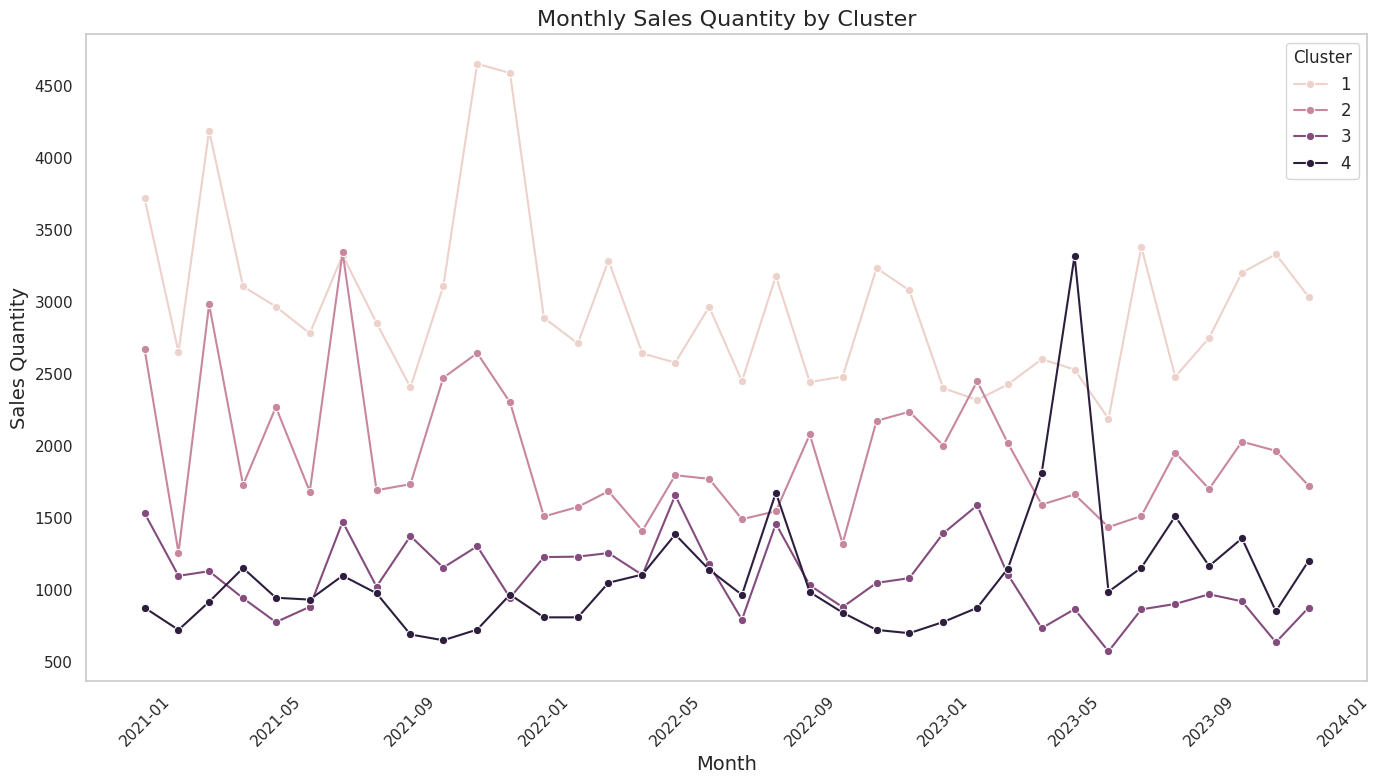

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 월별 cluster별 판매수량 시각화
monthly_cluster_sales = final_2.groupby(['판매월', 'cluster']).agg({'판매수량': 'sum',
                                                                    '한파': 'first',
                                                                    '폭염': 'first',
                                                                    '호우': 'first',
                                                                    '생활물가지수': 'first',
                                                                    '음식료품_계절조정지수': 'first'}).reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 클러스터별 판매수량 시각화
sns.lineplot(data=monthly_cluster_sales, x='판매월', y='판매수량', hue='cluster', marker='o')

# 그래프 제목 및 축 라벨 설정
plt.title('Monthly Sales Quantity by Cluster', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Sales Quantity', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Cluster', fontsize=12)
plt.grid()

# 그래프 표시
plt.tight_layout()
plt.show()

In [136]:
# 2. 2023-05의 cluster4 판매수량 대체
# cluster4의 판매수량 평균값 계산 (2021-01부터 2023-08까지)
mean_cluster4 = final_2[(final_2['판매월'] < '2023-09-01') & (final_2['cluster'] == 4)]['판매수량'].mean()

# 2023년 5월의 cluster4 판매수량을 평균값으로 대체
final_2.loc[(final_2['판매월'] == '2023-05-01') & (final_2['cluster'] == 4), '판매수량'] = mean_cluster4

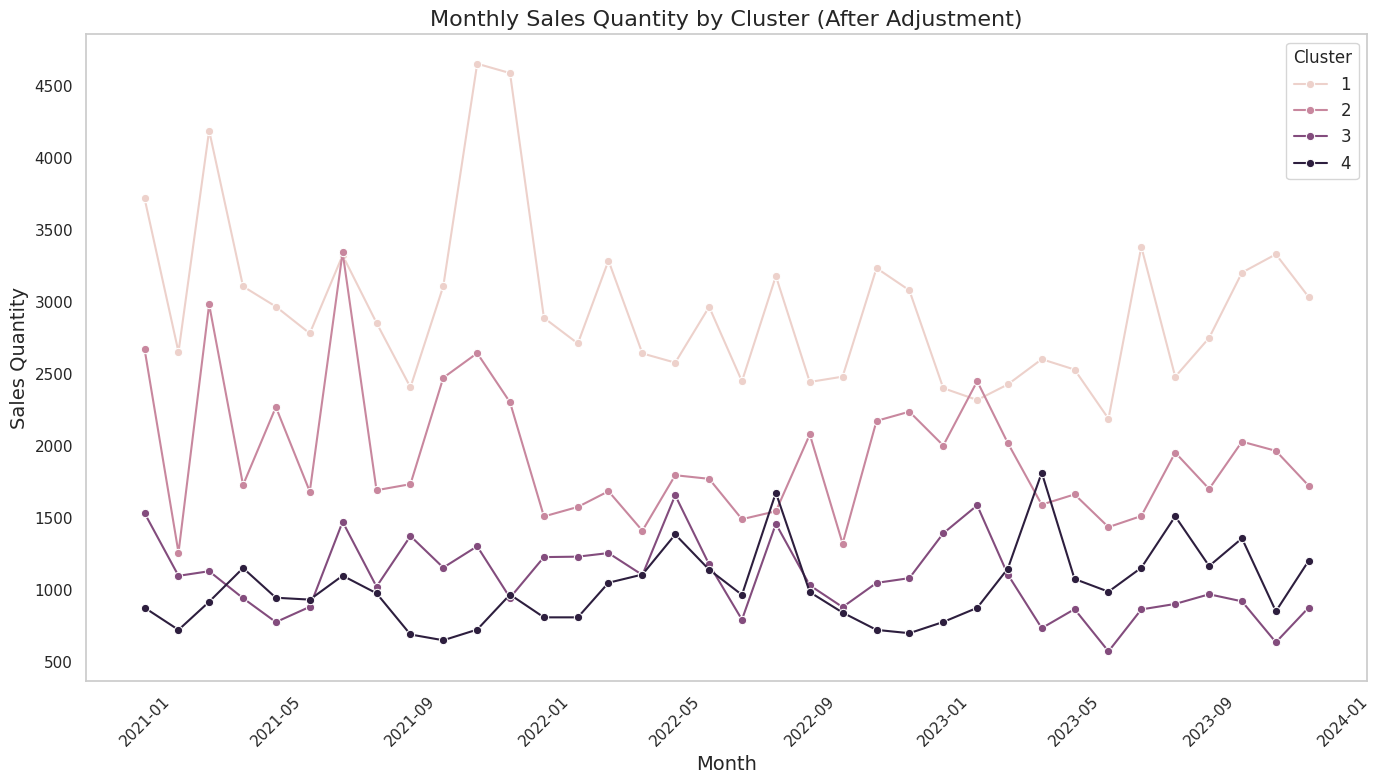

In [137]:
# 3. 대체한 후의 월별 cluster별 판매수량 시각화
monthly_cluster_sales_updated = final_2.groupby(['판매월', 'cluster']).agg({'판매수량': 'sum',
                                                                          '한파': 'first',
                                                                          '폭염': 'first',
                                                                          '호우': 'first',
                                                                          '생활물가지수': 'first',
                                                                          '음식료품_계절조정지수': 'first'}).reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 클러스터별 판매수량 시각화
sns.lineplot(data=monthly_cluster_sales_updated, x='판매월', y='판매수량', hue='cluster', marker='o')

# 그래프 제목 및 축 라벨 설정
plt.title('Monthly Sales Quantity by Cluster (After Adjustment)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Sales Quantity', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Cluster', fontsize=12)
plt.grid()

# 그래프 표시
plt.tight_layout()
plt.show()

---

## prophet

In [138]:
import pandas as pd
from prophet import Prophet

# final_2 데이터프레임이 이미 정의되어 있다고 가정

# 클러스터별 데이터프레임 분리
clusters = [1, 2, 3, 4]
cluster_dfs = {cluster: final_2[final_2['cluster'] == cluster].reset_index(drop=True) for cluster in clusters}

# 미래 예측 데이터 생성 (9월부터 12월까지)
future_months = pd.date_range(start='2023-09-01', periods=4, freq='M')

predictions = []

/tmp/ipykernel_2244251/66754711.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(start='2023-09-01', periods=4, freq='M')


In [139]:
# 각 클러스터에 대해 모델 학습 및 예측 수행
for cluster, cluster_df in cluster_dfs.items():
    # '판매월'과 '판매수량' 컬럼을 'ds'와 'y'로 이름 변경
    cluster_data = cluster_df.rename(columns={'판매월': 'ds', '판매수량': 'y'})

    # NaN 값 확인 및 처리
    cluster_data = cluster_data.dropna(subset=['ds', 'y'])  # NaN 값 제거

    # 날짜 형식 확인
    cluster_data['ds'] = pd.to_datetime(cluster_data['ds'])  # 날짜 형식으로 변환

    # 데이터 샘플 수 확인
    print(f"Cluster {cluster} - Dataframe shape: {cluster_data.shape}")

    # Prophet 모델 생성
    model = Prophet()

    # 모델 학습
    if cluster_data.shape[0] < 2:
        print(f"Not enough data to fit model for cluster {cluster}. Skipping...")
        continue  # 데이터가 부족하면 건너뜀

    model.fit(cluster_data)

    # 예측 수행
    future = pd.DataFrame({'ds': future_months})
    future['cluster'] = cluster  # 클러스터 정보 추가

    # 외생변수 값 예시
    future['한파'] = [5, 10, 15, 20]  # 예시 값, 적절히 조정 필요
    future['폭염'] = [0] * len(future)  # 비 오는 날의 비율을 반영
    future['호우'] = [1] * len(future)  # 비 오는 날의 비율을 반영
    future['생활물가지수'] = [105] * len(future)  # 적절한 값으로 수정
    future['음식료품_계절조정지수'] = [95] * len(future)  # 적절한 값으로 수정

    # 예측 수행
    forecast = model.predict(future)

    # 음수 예측 값 처리
    forecast['yhat'] = forecast['yhat'].clip(lower=0)  # 음수 값을 0으로 변환

    # 예측 결과 저장
    predictions_df = forecast[['ds', 'yhat']].rename(columns={'ds': '판매월', 'yhat': '판매수량_예측'})
    predictions_df['cluster'] = cluster  # 클러스터 정보 추가
    predictions.append(predictions_df)

11:02:28 - cmdstanpy - INFO - Chain [1] start processing
11:02:28 - cmdstanpy - INFO - Chain [1] done processing


Cluster 1 - Dataframe shape: (36, 8)


11:02:28 - cmdstanpy - INFO - Chain [1] start processing
11:02:28 - cmdstanpy - INFO - Chain [1] done processing


Cluster 2 - Dataframe shape: (36, 8)


11:02:29 - cmdstanpy - INFO - Chain [1] start processing
11:02:29 - cmdstanpy - INFO - Chain [1] done processing


Cluster 3 - Dataframe shape: (36, 8)


11:02:29 - cmdstanpy - INFO - Chain [1] start processing
11:02:29 - cmdstanpy - INFO - Chain [1] done processing


Cluster 4 - Dataframe shape: (36, 8)


In [140]:
# 모든 클러스터의 예측 결과를 하나의 데이터프레임으로 합치기
final_predictions = pd.concat(predictions, ignore_index=True)

# 결과 출력
print("\nPredictions for Sales Quantity (September to December 2023):")
print(final_predictions.sort_values(by=['판매월', 'cluster']))


Predictions for Sales Quantity (September to December 2023):
          판매월      판매수량_예측  cluster
0  2023-09-30  3835.806239        1
4  2023-09-30  1621.566869        2
8  2023-09-30  1227.828204        3
12 2023-09-30  1938.101207        4
1  2023-10-31  1903.806095        1
5  2023-10-31  1135.425327        2
9  2023-10-31     0.000000        3
13 2023-10-31   406.745323        4
2  2023-11-30  1986.212508        1
6  2023-11-30  1048.305796        2
10 2023-11-30  1100.627753        3
14 2023-11-30  1019.697630        4
3  2023-12-31  2220.564366        1
7  2023-12-31   423.344282        2
11 2023-12-31   900.127215        3
15 2023-12-31   192.687716        4


In [141]:
# 월별 판매량 합계 계산
monthly_sales_sum = final_predictions.groupby('판매월')['판매수량_예측'].sum().reset_index()
# 결과 출력
monthly_sales_sum

,판매월,판매수량_예측
0,2023-09-30,8623.302520
1,2023-10-31,3445.976745
2,2023-11-30,5154.843687
3,2023-12-31,3736.723578


In [142]:
# final_2에서 2023년 9월부터 12월까지의 데이터 필터링
filtered_data = final_2[(final_2['판매월'] >= '2023-09-01') & (final_2['판매월'] <= '2023-12-31')]

# 월별 판매수량 합계 계산
monthly_sales_sum_final_2 = filtered_data.groupby('판매월')['판매수량'].sum().reset_index()

# 결과 출력
monthly_sales_sum_final_2

,판매월,판매수량
0,2023-09-01,6598.0
1,2023-10-01,7522.0
2,2023-11-01,6795.0
3,2023-12-01,6848.0


In [145]:
# 판매월 형식 통일: 일(day) 값을 마지막 날로 변경
monthly_sales_sum_final_2['판매월'] = pd.to_datetime(monthly_sales_sum_final_2['판매월']).dt.to_period('M').dt.to_timestamp('M')

# 예측 판매수량 판매월 형식 확인
monthly_sales_sum['판매월'] = pd.to_datetime(monthly_sales_sum['판매월'])

# 데이터프레임 병합
merged_data = pd.merge(monthly_sales_sum, monthly_sales_sum_final_2, on='판매월', how='inner')

In [146]:
# MAPE 계산 함수
def calculate_mape(actual, predicted):
    return (abs(actual - predicted) / actual).mean() * 100

# MAPE 계산
mape = calculate_mape(merged_data['판매수량'], merged_data['판매수량_예측'])

In [147]:
merged_data

,판매월,판매수량_예측,판매수량
0,2023-09-30,8623.302520,6598.0
1,2023-10-31,3445.976745,7522.0
2,2023-11-30,5154.843687,6795.0
3,2023-12-31,3736.723578,6848.0


In [148]:
print(f"\nMAPE: {mape:.2f}%")


MAPE: 38.61%


---